In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [32]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [33]:
#df_raw = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/mosquitoes/mosquito_trajec.csv')
df_raw = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/terns/ALL_merged_d200div_d25curl.csv')
wind_direction = 0

In [47]:
df_raw = df_raw[df_raw.ID =='Tern1838-1-1'].iloc[0:1200] # taking only part since it is a long traj   # one from paper fig: 'Tern1803-1-44'

In [48]:
scaling = 1

In [49]:
df_calibrated = df_raw*scaling

In [50]:
# estimate time stamps: each point is 0.066 sec apart
timestamps = np.arange(0, df_calibrated.shape[0]*0.033, 0.033)

In [51]:
df_calibrated['timestamps_sec'] = timestamps

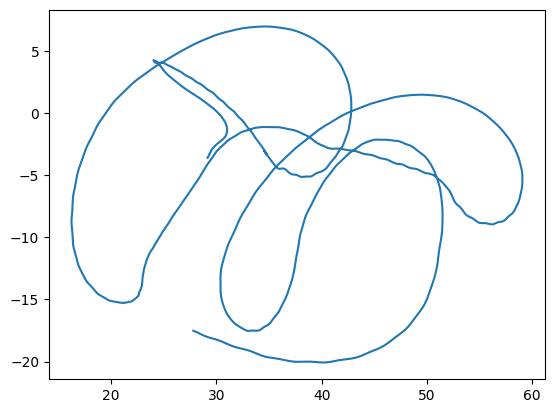

In [52]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

In [53]:
from scipy.interpolate import UnivariateSpline

In [54]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), 0.01)

In [55]:
interp_timestamps_sec

array([0.000e+00, 1.000e-02, 2.000e-02, ..., 3.954e+01, 3.955e+01,
       3.956e+01])

In [56]:
spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-4, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-4, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

In [57]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

In [58]:
len(df_calibrated.x)

1200

2.0


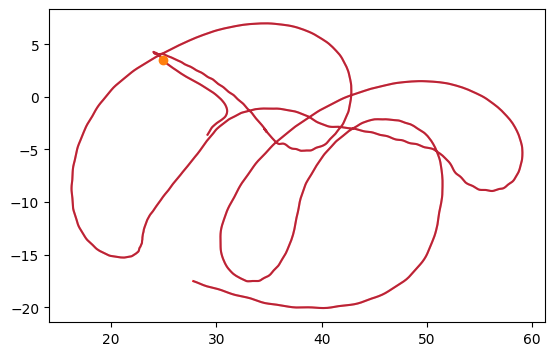

In [59]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values, color='r')
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, alpha=.3)

tix = 200
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

In [17]:
df_calibrated_interp

,timestamps_sec,x,y
0,0.00,29.164997,-3.606997
1,0.01,29.185245,-3.563867
2,0.02,29.208586,-3.530072
3,0.03,29.232801,-3.497978
4,0.04,29.256588,-3.463748
...,...,...,...
3952,39.52,28.280759,-17.693489
3953,39.53,28.184119,-17.653680
3954,39.54,28.085809,-17.614803
3955,39.55,27.985873,-17.577316


In [18]:
import pynumdiff

In [19]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [20]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'tern_a'
df_calibrated_interp['obj_id_unique'] = 'tern_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

NameError: name 'wind_direction' is not defined

In [ ]:
np.mean(np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2))

In [ ]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = 0.01
intercept=-3
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [651]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [653]:
trajec = df_calibrated_interp

In [655]:
trajec.shape

(8587, 11)

In [753]:
course = trajec.course_smoothish.values
abs_min_ix = tix
abs_max_ix = 8000
min_ix_range = 500
max_ix_range = 1500

In [ ]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 30, 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)

In [ ]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[1]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [ ]:
sorted_fit

In [ ]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[0]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [ ]:
import figurefirst as fifi

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50,500)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = np.round(dt*xticks,1)#['0','25','50']
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])